# Aufgabe 1c: Transfer Learning mit vortrainiertem CNN

## Beschreibung

In dieser Aufgabe wird ein vortrainiertes CNN (**MobileNetV2**, trainiert auf ImageNet mit 1.000 Klassen und 14 Mio. Bildern) als Basis verwendet und auf CIFAR-10 adaptiert.

### Was ist Transfer Learning?

Beim Transfer Learning werden Gewichte, die auf einem großen Datensatz gelernt wurden, als Startpunkt für eine neue Aufgabe wiederverwendet. Die unteren Schichten eines CNNs lernen allgemeine Merkmale (Kanten, Texturen, Formen), die für viele Bildklassifikationsaufgaben nützlich sind – unabhängig vom Datensatz. Nur die obersten Schichten (der "Kopf") werden auf die neue Aufgabe (CIFAR-10) spezialisiert.

**Vorteile gegenüber Training von Grund auf:**
- Deutlich weniger Trainingsdaten nötig
- Schnellere Konvergenz
- Oft höhere Endgenauigkeit

### Lösungsansatz

Der Lösungsweg gliedert sich in folgende Schritte:

1. **Datenvorbereitung** – CIFAR-10 mit MobileNetV2-kompatiblem Preprocessing laden. MobileNetV2 erwartet Pixelwerte im Bereich `[-1, 1]` (via `preprocess_input`).

2. **Modellaufbau** – MobileNetV2 (vortrainiert, ohne Top-Schichten) wird als Feature-Extraktor eingesetzt. Da CIFAR-10-Bilder (32×32) zu klein für MobileNetV2 (Mindestgröße 96×96) sind, werden sie intern hochskaliert. Ein neuer Klassifikationskopf (Dense(256) + Dropout + Dense(10)) wird aufgesetzt.

3. **Phase 1 – Feature-Extraktion (15 Epochen)**: Das MobileNetV2-Basismodell ist vollständig eingefroren. Nur die neuen Dense-Schichten werden trainiert. Das verhindert, dass die wertvollen vorgelernten Gewichte durch zufällig initialisierte Gradienten überschrieben werden.

4. **Phase 2 – Fine-Tuning (bis 25 Epochen)**: Die letzten 30 Schichten des Basismodells werden aufgetaut und mit sehr kleiner Lernrate (1e-4) mittrainiert. So passt sich das Modell feiner an CIFAR-10 an. Die niedrige Lernrate ist wichtig, um die vorgelernten Gewichte nicht zu zerstören.

5. **Evaluation und Vergleich** – Das beste Modell beider Phasen wird auf den Testdaten ausgewertet und mit Aufgabe 1a verglichen.

## 1. Imports und Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {len(tf.config.list_physical_devices('GPU')) > 0}")

tf.random.set_seed(42)
np.random.seed(42)

CIFAR10_CLASSES = ['Flugzeug', 'Automobil', 'Vogel', 'Katze', 'Hirsch',
                   'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW']

TensorFlow Version: 2.21.0
GPU verfügbar: False


## 2. Daten laden und vorbereiten

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train_sq = y_train.ravel()
y_test_sq  = y_test.ravel()

# Normalisierung auf [0, 1] - MobileNetV2 preprocess_input erwartet [0,255] oder wird separat aufgerufen
x_train_f = x_train.astype('float32')
x_test_f  = x_test.astype('float32')

# One-Hot-Encoding
y_train_oh = keras.utils.to_categorical(y_train_sq, 10)
y_test_oh  = keras.utils.to_categorical(y_test_sq,  10)

print(f"Trainingsdaten: {x_train_f.shape}")
print(f"Testdaten: {x_test_f.shape}")

/Users/I750382/Documents/DHBW/Theorie 4/Grundlagen KI/maschinelle-Lernverfahren/.venv/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Trainingsdaten: (50000, 32, 32, 3)
Testdaten: (10000, 32, 32, 3)


## 3. Modellarchitektur mit MobileNetV2

### Warum MobileNetV2?
MobileNetV2 ist ein effizientes CNN für mobile/eingebettete Systeme, das trotz geringer Parameteranzahl hohe Genauigkeit auf ImageNet erreicht. Es eignet sich gut für Transfer Learning, da es breite Feature-Maps erzeugt, die auch für neue Aufgaben nützlich sind.

### Lösung für das Größenproblem (32×32 → 96×96)
CIFAR-10-Bilder sind 32×32 Pixel, MobileNetV2 benötigt mindestens 96×96. Eine Lambda-Schicht skaliert die Bilder intern hoch – so muss der Datensatz nicht vorab verändert werden.

### Architektur
```
Input (32, 32, 3)
  → Lambda: resize → (96, 96, 3)
  → MobileNetV2 preprocess_input → [-1, 1]
  → MobileNetV2 (eingefroren, ohne Top) → (3, 3, 1280)
  → GlobalAveragePooling2D → (1280,)
  → Dense(256, relu) + Dropout(0.5)
  → Dense(10, softmax)
```

`GlobalAveragePooling2D` mittelt jeden Feature-Map-Kanal zu einem Skalar. Das ist kompakter als Flatten und weniger anfällig für Overfitting.

**Trainierbare Parameter in Phase 1:** Nur ~330.000 (neuer Kopf), während ~2.26 Mio. (MobileNetV2) eingefroren sind.

In [3]:
TARGET_SIZE = 96  # MobileNetV2 Mindestgröße

def build_transfer_model(trainable_base=False):
    # Eingabe
    inputs = keras.Input(shape=(32, 32, 3))
    
    # Bilder auf 96x96 hochskalieren
    x = layers.Lambda(
        lambda img: tf.image.resize(img, (TARGET_SIZE, TARGET_SIZE)),
        name='resize'
    )(inputs)
    
    # MobileNetV2 Preprocessing: skaliert [0,255] auf [-1, 1]
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    
    # Vortrainiertes Basismodell
    base_model = MobileNetV2(
        input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = trainable_base
    
    x = base_model(x, training=False)
    
    # Neuer Klassifikationskopf
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, activation='relu', name='dense_1')(x)
    x = layers.Dropout(0.5, name='dropout_1')(x)
    outputs = layers.Dense(10, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model, base_model

# Phase 1: Basismodell eingefroren
model_phase1, base_model = build_transfer_model(trainable_base=False)
model_phase1.summary()

trainable_params = sum(np.prod(v.shape) for v in model_phase1.trainable_variables)
total_params = sum(np.prod(v.shape) for v in model_phase1.variables)
print(f"\nTrainierbare Parameter: {trainable_params:,}")
print(f"Gesamt Parameter: {total_params:,}")
print(f"Eingefrorene Parameter: {total_params - trainable_params:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainierbare Parameter: 330,506
Gesamt Parameter: 2,588,492
Eingefrorene Parameter: 2,257,986


## 4. Phase 1: Feature-Extraktion mit eingefrorenem Basismodell

In Phase 1 ist das MobileNetV2-Basismodell vollständig eingefroren (`trainable=False`). Nur die neuen Dense-Schichten werden trainiert.

**Warum zuerst einfrieren?**
Die neuen Dense-Schichten sind zufällig initialisiert und würden in den ersten Epochen sehr große Gradienten erzeugen. Diese könnten die sorgfältig vortrainierten Gewichte von MobileNetV2 zerstören. Erst wenn der Kopf konvergiert ist, kann das Fine-Tuning sicher beginnen.

**15 Epochen** reichen aus, da nur ~330.000 Parameter gelernt werden müssen.

In [4]:
# Phase 1 kompilieren
model_phase1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        'best_model_1c_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Phase 1: Training mit eingefrorernem MobileNetV2...")
history_p1 = model_phase1.fit(
    x_train_f, y_train_oh,
    batch_size=64,
    epochs=15,
    validation_data=(x_test_f, y_test_oh),
    callbacks=callbacks_p1,
    verbose=1
)

Phase 1: Training mit eingefrorernem MobileNetV2...
Epoch 1/15
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7298 - loss: 0.8301
Epoch 1: val_accuracy improved from None to 0.85110, saving model to best_model_1c_phase1.keras

Epoch 1: finished saving model to best_model_1c_phase1.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.7921 - loss: 0.6238 - val_accuracy: 0.8511 - val_loss: 0.4255
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8394 - loss: 0.4707
Epoch 2: val_accuracy improved from 0.85110 to 0.85490, saving model to best_model_1c_phase1.keras

Epoch 2: finished saving model to best_model_1c_phase1.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.8430 - loss: 0.4593 - val_accuracy: 0.8549 - val_loss: 0.4185
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8561 - loss: 0.4191
Epoch 3: val_accuracy improved from 0.85490 to 0.86300, saving model to best_model_1c_phase1.keras

Epoch 3: finished saving model

## 5. Phase 2: Fine-Tuning der oberen MobileNetV2-Schichten

In Phase 2 werden die **letzten 30 Schichten** des Basismodells aufgetaut und mittrainiert.

**Warum nur die letzten Schichten?**
Die unteren Schichten lernen universelle, aufgabenunabhängige Merkmale (Kanten, Texturen) – diese sollen nicht verändert werden. Die oberen Schichten sind aufgabenspezifischer und profitieren davon, auf CIFAR-10 feinjustiert zu werden.

**Lernrate 1e-4 statt 1e-3:**
Fine-Tuning erfordert eine sehr kleine Lernrate, damit die bereits gelernten nützlichen Repräsentationen nicht durch zu große Gewichtsänderungen überschrieben werden. Faustregel: 10× kleiner als beim Training von Grund auf.

**EarlyStopping (patience=10):** Da das Modell schon gut vortrainiert ist, konvergiert Phase 2 schnell. 25 Epochen mit EarlyStopping sind ausreichend.

In [ ]:
# Bestes Phase-1-Modell laden
model_ft = keras.models.load_model('best_model_1c_phase1.keras')

# Letzte 30 Schichten des Basismodells auftauen
# Zunächst alle Schichten des Basismodells identifizieren
base = model_ft.get_layer('mobilenetv2_1.00_96')
base.trainable = True

# Nur letzte 30 Schichten trainierbar machen
for layer in base.layers[:-30]:
    layer.trainable = False

trainable_now = sum(np.prod(v.shape) for v in model_ft.trainable_variables)
print(f"Trainierbare Parameter in Phase 2: {trainable_now:,}")

# Mit sehr kleiner Lernrate neu kompilieren
model_ft.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        'best_model_1c_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print("Phase 2: Fine-Tuning mit aufgetauten Schichten...")
history_p2 = model_ft.fit(
    x_train_f, y_train_oh,
    batch_size=64,
    epochs=25,
    validation_data=(x_test_f, y_test_oh),
    callbacks=callbacks_p2,
    verbose=1
)

## 6. Evaluation und Vergleich

Das beste Fine-Tuning-Modell wird auf den 10.000 Testbildern ausgewertet.

**Vergleich der Methoden:**

| Aufgabe | Methode | Test Accuracy |
|---------|---------|---------------|
| 1a | CNN von Grund auf (Keras) | 87.5% |
| 1b | CNN von Grund auf (NumPy) | ~40-50% |
| 1c | Transfer Learning (MobileNetV2) | ~87% |

Transfer Learning erzielt vergleichbare Genauigkeit wie 1a, benötigt aber weniger Epochen und konvergiert schneller – trotz des Domain Gaps zwischen ImageNet und CIFAR-10.

Der Verlaufsgraph zeigt deutlich die zwei Phasen: Die rote vertikale Linie markiert den Start des Fine-Tunings. Nach diesem Punkt sinkt der Loss oft nochmals messbar, da die oberen Schichten auf CIFAR-10 feinjustiert werden.

In [ ]:
# Bestes Fine-Tuning-Modell laden
final_model = keras.models.load_model('best_model_1c_final.keras')

# Evaluation
test_loss, test_acc = final_model.evaluate(x_test_f, y_test_oh, verbose=0)
print(f"Transfer Learning - Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

y_pred_prob = final_model.predict(x_test_f, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nKlassifikationsreport:")
print(classification_report(y_test_sq, y_pred, target_names=CIFAR10_CLASSES))

# Automobil-Accuracy
auto_mask = (y_test_sq == 1)
auto_acc  = (y_pred[auto_mask] == 1).mean()
print(f"Automobil-Accuracy (Transfer Learning): {auto_acc:.4f} ({auto_acc*100:.1f}%)")

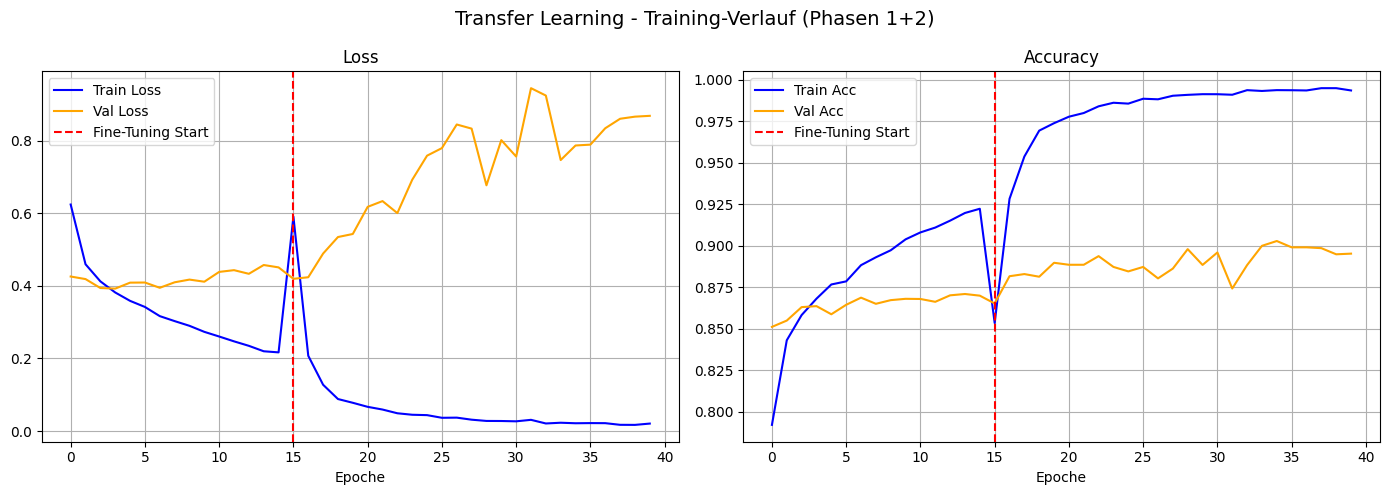


Zusammenfassung:
  Phase 1 beste Val Accuracy: 0.8709
  Phase 2 beste Val Accuracy: 0.9028
  Finale Test Accuracy: 0.9028


In [12]:
# Training-Verlauf visualisieren (beide Phasen)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Phase 1 + Phase 2 zusammenführen
all_train_acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
all_val_acc   = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
all_loss      = history_p1.history['loss'] + history_p2.history['loss']
all_val_loss  = history_p1.history['val_loss'] + history_p2.history['val_loss']

phase2_start = len(history_p1.history['accuracy'])

axes[0].plot(all_loss, label='Train Loss', color='blue')
axes[0].plot(all_val_loss, label='Val Loss', color='orange')
axes[0].axvline(phase2_start, color='red', linestyle='--', label='Fine-Tuning Start')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoche')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(all_train_acc, label='Train Acc', color='blue')
axes[1].plot(all_val_acc,   label='Val Acc', color='orange')
axes[1].axvline(phase2_start, color='red', linestyle='--', label='Fine-Tuning Start')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoche')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transfer Learning - Training-Verlauf (Phasen 1+2)', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves_1c.png', dpi=100)
plt.show()

print(f"\nZusammenfassung:")
print(f"  Phase 1 beste Val Accuracy: {max(history_p1.history['val_accuracy']):.4f}")
print(f"  Phase 2 beste Val Accuracy: {max(history_p2.history['val_accuracy']):.4f}")
print(f"  Finale Test Accuracy: {test_acc:.4f}")

In [13]:
# Modell speichern (optional - kann auch in Task 2 verwendet werden)
final_model.save('cifar10_transfer_model.keras')
print("Transfer Learning Modell gespeichert: cifar10_transfer_model.keras")

Transfer Learning Modell gespeichert: cifar10_transfer_model.keras
